In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, validation_curve, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from scipy.stats import chi2_contingency

SEED = 42

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    r, k = table.shape
    if min(r, k) < 2:
        return np.nan
    chi2_stat = chi2_contingency(table)[0]
    n = table.sum().sum()
    return np.sqrt(chi2_stat / (n * (min(r, k) - 1)))

enc = OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

pipe_lr = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    LogisticRegression(max_iter=1000)
)

pipe_selectk = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    SelectKBest(chi2, k=40),
    LogisticRegression(max_iter=1000)
)
pipe_rf = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    RandomForestClassifier(n_estimators=200, random_state=SEED)
)
pipe_tree = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    DecisionTreeClassifier(random_state=SEED)
)

In [80]:
df = pd.read_csv('mushrooms.csv')

In [81]:
for x in df.keys():
    print(x, df[x].nunique())

class 2
cap-shape 6
cap-surface 4
cap-color 10
bruises 2
odor 9
gill-attachment 2
gill-spacing 2
gill-size 2
gill-color 12
stalk-shape 2
stalk-root 5
stalk-surface-above-ring 4
stalk-surface-below-ring 4
stalk-color-above-ring 9
stalk-color-below-ring 9
veil-type 1
veil-color 4
ring-number 3
ring-type 5
spore-print-color 9
population 6
habitat 7


**veil-type - константа**

In [103]:
print("Баланс классов:")
print(df['class'].value_counts(normalize=True))

print("\nПропуски (замаскированы как '?'):")
print((df == '?').sum()[lambda s: s > 0])

Баланс классов:
class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

Пропуски (замаскированы как '?'):
stalk-root    2480
dtype: int64


**Классы сбалансированы**, поэтому accuracy здесь не вводит
в заблуждение.
**Пропуски**: 2480 строк в stalk-root закодированы как '?' — формально это
отдельная категория, OneHotEncoder обработает её как обычное значение.

In [82]:
cols = df.columns
n = len(cols)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

for i in cols:
    for j in cols:
        corr_matrix.loc[i, j] = cramers_v(df[i], df[j])

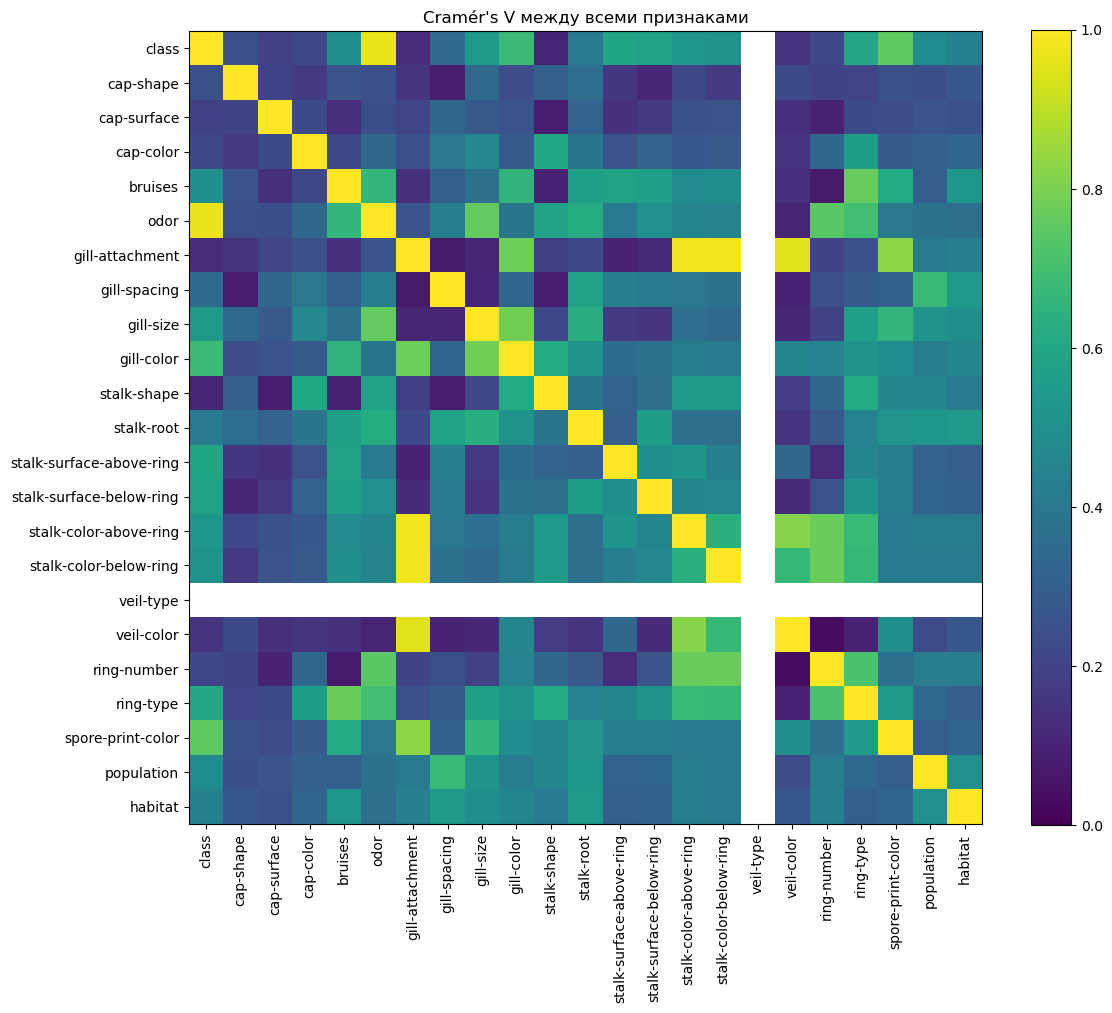

In [83]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap='viridis', vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(n))
ax.set_yticklabels(cols)

fig.colorbar(im, ax=ax)
ax.set_title("Cramér's V между всеми признаками")
plt.tight_layout()
plt.show()

**odor сильно коррелирует с class**, 
**многие признаки вообще не влияют на class**

In [84]:
X = df.drop('class', axis=1)
Y = df['class'].map({'e' : 0, 'p' : 1})
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y, random_state=SEED)
X_train_enc = enc.fit_transform(X_train)
X_test_enc = enc.transform(X_test)

### Гипотеза 1

In [91]:
results = {}
for k in [5, 10, 20, 40, 50]:
    pipe_k = make_pipeline(
        OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        SelectKBest(chi2, k=k),
        LogisticRegression(max_iter=1000)
    )
    results[k] = cross_val_score(pipe_k, X_train, Y_train, cv=cv, scoring='roc_auc')
scores_full = cross_val_score(LogisticRegression(max_iter=1000), X_train_enc, Y_train, cv=cv, scoring='roc_auc')
print(f"Полный набор признаков: ROC-AUC = {scores_full.mean():.4f} ± {scores_full.std():.4f}")
print("SelectKBest(k):")
for k, scores in results.items(): 
    print(f"k={k:2d}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Полный набор признаков: ROC-AUC = 1.0000 ± 0.0000
SelectKBest(k):
k= 5: ROC-AUC = 0.9738 ± 0.0040
k=10: ROC-AUC = 0.9850 ± 0.0043
k=20: ROC-AUC = 0.9964 ± 0.0006
k=40: ROC-AUC = 0.9999 ± 0.0001
k=50: ROC-AUC = 1.0000 ± 0.0000


При k >= 50 значения неотличимы, значит **гипотеза 1 верна**.
Значит 50 бинарных признаков позволяет достич модели качества полного набора признаков(112)

### Гипотеза 2

In [94]:
X_no_veil = X.drop(columns='veil-type')
X_train_nv, X_test_nv, _, _ = train_test_split(X_no_veil, Y, stratify=Y, test_size=0.25, random_state=SEED)

scores_lr_with = cross_val_score(pipe_lr, X_train, Y_train, cv=cv, scoring='roc_auc')
scores_lr_without = cross_val_score(pipe_lr, X_train_nv, Y_train, cv=cv, scoring='roc_auc')
print(f"LogReg с veil-type:    ROC-AUC = {scores_lr_with.mean():.4f} ± {scores_lr_with.std():.4f}")
print(f"LogReg без veil-type:  ROC-AUC = {scores_lr_without.mean():.4f} ± {scores_lr_without.std():.4f}")

scores_tree_with = cross_val_score(pipe_tree, X_train, Y_train, cv=cv, scoring='roc_auc')
scores_tree_without = cross_val_score(pipe_tree, X_train_nv, Y_train, cv=cv, scoring='roc_auc')
print(f"Tree с veil-type:      ROC-AUC = {scores_tree_with.mean():.4f} ± {scores_tree_with.std():.4f}")
print(f"Tree без veil-type:    ROC-AUC = {scores_tree_without.mean():.4f} ± {scores_tree_without.std():.4f}")

scores_rf_with = cross_val_score(pipe_rf, X_train, Y_train, cv=cv, scoring='roc_auc')
scores_rf_without = cross_val_score(pipe_rf, X_train_nv, Y_train, cv=cv, scoring='roc_auc')
print(f"RF с veil-type:        ROC-AUC = {scores_rf_with.mean():.4f} ± {scores_rf_with.std():.4f}")
print(f"RF без veil-type:      ROC-AUC = {scores_rf_without.mean():.4f} ± {scores_rf_without.std():.4f}")

LogReg с veil-type:    ROC-AUC = 1.0000 ± 0.0000
LogReg без veil-type:  ROC-AUC = 1.0000 ± 0.0000
Tree с veil-type:      ROC-AUC = 0.9998 ± 0.0003
Tree без veil-type:    ROC-AUC = 0.9998 ± 0.0003
RF с veil-type:        ROC-AUC = 1.0000 ± 0.0000
RF без veil-type:      ROC-AUC = 1.0000 ± 0.0000


Скоры абсолютно неотличимы на трех разных моделях, значит **гипотеза верна**, константные признаки не влияют на предсказание модели

### Гипотеза 3

In [96]:
pipe_odor_only = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    LogisticRegression(max_iter=1000)
)

X_train_odor = X_train[['odor']]

scores_odor_acc = cross_val_score(pipe_odor_only, X_train_odor, Y_train, cv=cv, scoring='accuracy')
scores_odor_auc = cross_val_score(pipe_odor_only, X_train_odor, Y_train, cv=cv, scoring='roc_auc')

print(f"Только odor: accuracy = {scores_odor_acc.mean():.4f} ± {scores_odor_acc.std():.4f}")
print(f"Только odor: ROC-AUC  = {scores_odor_auc.mean():.4f} ± {scores_odor_auc.std():.4f}")

Только odor: accuracy = 0.9846 ± 0.0039
Только odor: ROC-AUC  = 0.9870 ± 0.0033


Данная особенность датасета подтвердилась, odor почти полностью решает задачу, **гипотеза верна**

### Гипотеза 4

In [98]:
scores_tree = cross_val_score(pipe_tree, X_train, Y_train, cv=cv, scoring='roc_auc')
scores_rf = cross_val_score(pipe_rf, X_train, Y_train, cv=cv, scoring='roc_auc')

print(f"DecisionTree:  ROC-AUC = {scores_tree.mean():.4f} ± {scores_tree.std():.4f}")
print(f"RandomForest:  ROC-AUC = {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")
print(f"Разница: {abs(scores_tree.mean() - scores_rf.mean()):.4f}")

DecisionTree:  ROC-AUC = 0.9998 ± 0.0003
RandomForest:  ROC-AUC = 1.0000 ± 0.0000
Разница: 0.0002


Разница незначительна, значит **гипотеза верна**

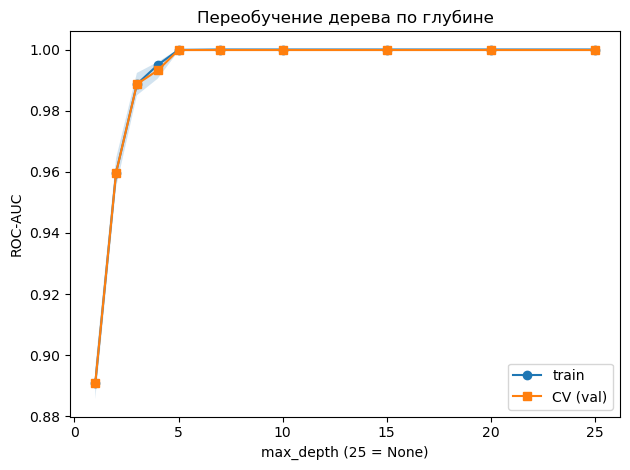

In [101]:
depths = [1, 2, 3, 4, 5, 7, 10, 15, 20, None]
depths_x = [d if d is not None else 25 for d in depths]

train_scores, val_scores = validation_curve(
    pipe_tree, X_train, Y_train,
    param_name='decisiontreeclassifier__max_depth',
    param_range=depths, cv=cv, scoring='roc_auc'
)

fig, ax = plt.subplots()
ax.plot(depths_x, train_scores.mean(axis=1), 'o-', label='train')
ax.plot(depths_x, val_scores.mean(axis=1), 's-', label='CV (val)')
ax.fill_between(depths_x, val_scores.mean(axis=1)-val_scores.std(axis=1),
                 val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.2)
ax.set_xlabel('max_depth (25 = None)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Переобучение дерева по глубине')
ax.legend()
plt.tight_layout()
plt.show()

In [105]:
pipe_tree_limited = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    DecisionTreeClassifier(max_depth=3, random_state=SEED)
)
pipe_tree_full = make_pipeline(
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    DecisionTreeClassifier(max_depth=None, random_state=SEED)
)

pipe_tree_limited.fit(X_train, Y_train)
pipe_tree_full.fit(X_train, Y_train)

auc_lim_train = roc_auc_score(Y_train, pipe_tree_limited.predict_proba(X_train)[:, 1])
auc_lim_test = roc_auc_score(Y_test, pipe_tree_limited.predict_proba(X_test)[:, 1])
auc_full_train = roc_auc_score(Y_train, pipe_tree_full.predict_proba(X_train)[:, 1])
auc_full_test = roc_auc_score(Y_test, pipe_tree_full.predict_proba(X_test)[:, 1])

print(f"max_depth=3:    train={auc_lim_train:.4f}, test={auc_lim_test:.4f}, разрыв={auc_lim_train-auc_lim_test:.4f}")
print(f"max_depth=None: train={auc_full_train:.4f}, test={auc_full_test:.4f}, разрыв={auc_full_train-auc_full_test:.4f}")

max_depth=3:    train=0.9887, test=0.9856, разрыв=0.0031
max_depth=None: train=1.0000, test=1.0000, разрыв=0.0000


При увеличении max_depth ROC-AUC монотонно растет, значит при увеличении max_depth модель не переобучается, поэтому **Гипотеза верна**

In [106]:
param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 7, 10, None],
    'decisiontreeclassifier__min_samples_leaf': [1, 5, 10]
}
gs = GridSearchCV(pipe_tree, param_grid, cv=cv, scoring='roc_auc')
gs.fit(X_train, Y_train)

print("Лучшие параметры:", gs.best_params_)
print(f"Лучший CV ROC-AUC: {gs.best_score_:.4f}")

Лучшие параметры: {'decisiontreeclassifier__max_depth': 7, 'decisiontreeclassifier__min_samples_leaf': 5}
Лучший CV ROC-AUC: 1.0000


In [107]:
from sklearn.metrics import classification_report

best_model = gs.best_estimator_
Y_pred = best_model.predict(X_test)

print(classification_report(Y_test, Y_pred, target_names=['edible', 'poisonous']))
print(f"ROC-AUC на test: {roc_auc_score(Y_test, best_model.predict_proba(X_test)[:, 1]):.4f}")

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00      1052
   poisonous       1.00      1.00      1.00       979

    accuracy                           1.00      2031
   macro avg       1.00      1.00      1.00      2031
weighted avg       1.00      1.00      1.00      2031

ROC-AUC на test: 1.0000
